In [21]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

model = Sequential()

# First LSTM Layer
model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(Dropout(0.2))

# Second LSTM Layer
model.add(
    LSTM(
        units=32,
        return_sequences=False
    )
)

model.add(Dropout(0.2))

# Dense Output Layer
model.add(Dense(1))

In [2]:
df = pd.read_csv("../data/processed/final_processed.csv")

df['Date'] = pd.to_datetime(df['Date'])

In [3]:
state_df = df[df['State'] == 'California'].copy()

In [4]:
state_df = state_df[['Date', 'Sales']]

In [5]:
state_df = state_df.sort_values('Date')

In [7]:
scaler = MinMaxScaler()

scaled_sales = scaler.fit_transform(
    state_df[['Sales']]
)

In [8]:
sequence_length = 30

In [9]:
X = []
y = []

for i in range(sequence_length, len(scaled_sales)):
    
    X.append(
        scaled_sales[i-sequence_length:i]
    )
    
    y.append(
        scaled_sales[i]
    )

X = np.array(X)

y = np.array(y)

In [10]:
print(X.shape)

(1757, 30, 1)


In [11]:
forecast_horizon = 56

In [12]:
X_train = X[:-forecast_horizon]

X_valid = X[-forecast_horizon:]

y_train = y[:-forecast_horizon]

y_valid = y[-forecast_horizon:]

In [13]:
model = Sequential()

In [14]:
model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

d:\forecasting_system\project\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
model.add(Dropout(0.2))

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)



In [27]:
model.compile(
    optimizer='adam',
    loss='mse'
)

In [28]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_valid, y_valid),
    callbacks=[early_stop]
)

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0256 - val_loss: 0.0014
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0095 - val_loss: 0.0019
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0089 - val_loss: 7.7865e-04
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0084 - val_loss: 3.9322e-04
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0081 - val_loss: 6.4751e-04
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0082 - val_loss: 0.0011
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0073 - val_loss: 6.4428e-04
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0062 - val_loss: 0.0017
Epoch 9/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0062 - val_loss: 4.9404e-04


In [30]:
predictions = model.predict(X_valid)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


In [31]:
predictions = scaler.inverse_transform(predictions)

y_valid_actual = scaler.inverse_transform(y_valid)

In [32]:
predictions = predictions.flatten()

y_valid_actual = y_valid_actual.flatten()

In [36]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

mae = mean_absolute_error(
    y_valid_actual,
    predictions
)

print("MAE:", mae)

MAE: 4314511.342596352


In [37]:
rmse = np.sqrt(
    mean_squared_error(
        y_valid_actual,
        predictions
    )
)

print("RMSE:", rmse)

RMSE: 10187611.823728222


In [38]:
valid_dates = state_df['Date'].iloc[-forecast_horizon:]

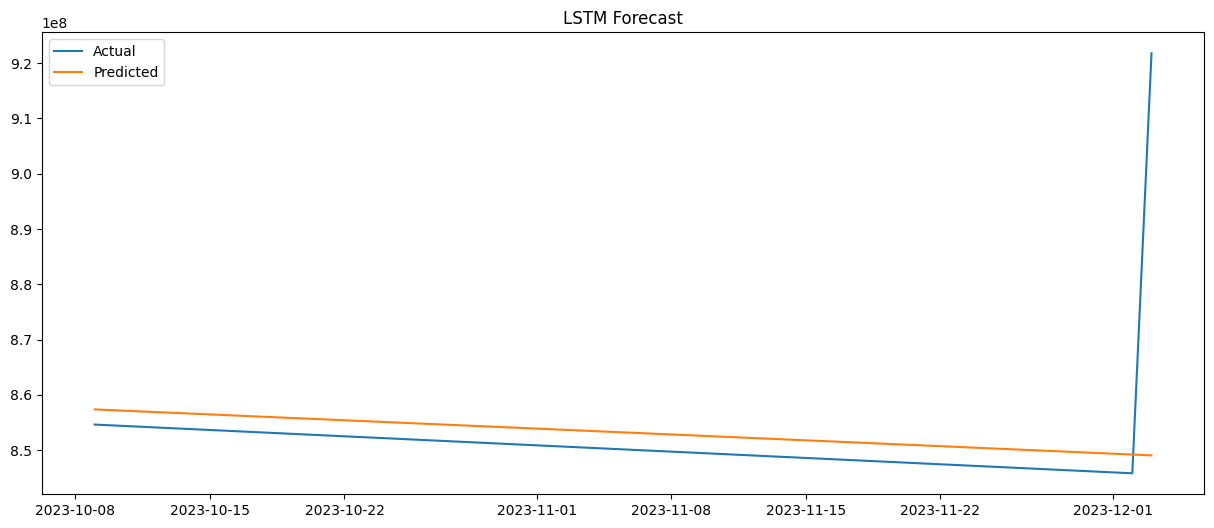

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    valid_dates,
    y_valid_actual,
    label='Actual'
)

plt.plot(
    valid_dates,
    predictions,
    label='Predicted'
)

plt.legend()

plt.title("LSTM Forecast")

plt.show()

In [40]:
model.save("../models/lstm_model.keras")